# Supply chain demand and inventory optimization with python

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("supply_chain_data.csv")
df.head()

,Date,Store_ID,Product_ID,Category,Region,Inventory_Level,Units_Sold,Units_Ordered,Price,Discount,Promotion,Weather_Condition,Competitor_Pricing,Seasonality,Epidemic,Demand
0,2025-01-01,S004,P007,Accessories,North,83,24,0,655.94,0.0,0,Cloudy,692.74,Winter,0,24
1,2025-01-02,S002,P004,Electronics,South,60,24,0,24755.52,5.0,1,Cloudy,24998.02,Winter,1,24
2,2025-01-03,S003,P008,Office,South,23,11,0,11774.86,0.0,0,Rainy,11818.92,Winter,1,11
3,2025-01-04,S003,P005,Electronics,South,106,29,0,19453.72,20.0,1,Cloudy,18254.65,Winter,0,29
4,2025-01-05,S003,P007,Accessories,North,140,27,0,1167.35,0.0,0,Sunny,1234.62,Winter,0,27


In [3]:
df.shape

(502, 16)

In [4]:
df.columns

Index(['Date', 'Store_ID', 'Product_ID', 'Category', 'Region',
       'Inventory_Level', 'Units_Sold', 'Units_Ordered', 'Price', 'Discount',
       'Promotion', 'Weather_Condition', 'Competitor_Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

In [5]:
df.dtypes

Date                   object
Store_ID               object
Product_ID             object
Category               object
Region                 object
Inventory_Level         int64
Units_Sold              int64
Units_Ordered           int64
Price                 float64
Discount              float64
Promotion               int64
Weather_Condition      object
Competitor_Pricing    float64
Seasonality            object
Epidemic                int64
Demand                  int64
dtype: object

## Data Cleaning

In [6]:
df["Date"] = pd.to_datetime(df["Date"])

In [7]:
df.dtypes

Date                  datetime64[ns]
Store_ID                      object
Product_ID                    object
Category                      object
Region                        object
Inventory_Level                int64
Units_Sold                     int64
Units_Ordered                  int64
Price                        float64
Discount                     float64
Promotion                      int64
Weather_Condition             object
Competitor_Pricing           float64
Seasonality                   object
Epidemic                       int64
Demand                         int64
dtype: object

In [8]:
df.isnull().sum()

Date                  0
Store_ID              0
Product_ID            0
Category              0
Region                0
Inventory_Level       0
Units_Sold            0
Units_Ordered         0
Price                 0
Discount              2
Promotion             0
Weather_Condition     1
Competitor_Pricing    1
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [9]:
df.describe()

,Date,Inventory_Level,Units_Sold,Units_Ordered,Price,Discount,Promotion,Competitor_Pricing,Epidemic,Demand
count,502,502.000000,502.000000,502.000000,502.000000,500.000000,502.000000,501.000000,502.000000,502.000000
mean,2025-09-07 00:05:44.223107584,81.784861,27.398406,2.872510,20361.373546,4.190000,0.247012,20305.632735,0.045817,27.687251
min,2025-01-01 00:00:00,5.000000,0.000000,0.000000,-849.580000,0.000000,0.000000,-890.850000,0.000000,4.000000
25%,2025-05-05 06:00:00,48.000000,19.000000,0.000000,2724.125000,0.000000,0.000000,2727.470000,0.000000,19.000000
50%,2025-09-06 12:00:00,73.500000,25.000000,0.000000,16839.115000,0.000000,0.000000,15779.760000,0.000000,26.000000
75%,2026-01-09 18:00:00,103.000000,33.000000,0.000000,30311.430000,5.000000,0.000000,31266.280000,0.000000,33.000000
max,2026-05-15 00:00:00,282.000000,73.000000,93.000000,61510.120000,20.000000,1.000000,64776.270000,1.000000,73.000000
std,NaN,48.092243,12.930362,11.071699,18740.190351,6.013837,0.431704,18728.378412,0.209296,12.661405


In [10]:
median_discount = df.loc[df["Promotion"] == 1, "Discount"].median()
median_discount

np.float64(15.0)

In [11]:
df.loc[
    (df["Promotion"] == 1) & (df["Discount"].isna()),
    "Discount"
] = median_discount

In [12]:
df.isnull().sum()

Date                  0
Store_ID              0
Product_ID            0
Category              0
Region                0
Inventory_Level       0
Units_Sold            0
Units_Ordered         0
Price                 0
Discount              2
Promotion             0
Weather_Condition     1
Competitor_Pricing    1
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [13]:
df.loc[
    (df["Promotion"] == 0) & (df["Discount"].isna()),
    "Discount"
] = 0

In [14]:
df.isnull().sum()

Date                  0
Store_ID              0
Product_ID            0
Category              0
Region                0
Inventory_Level       0
Units_Sold            0
Units_Ordered         0
Price                 0
Discount              0
Promotion             0
Weather_Condition     1
Competitor_Pricing    1
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [15]:
df["Competitor_Pricing"] = df["Competitor_Pricing"].fillna(
    df["Competitor_Pricing"].median()
)

In [16]:
df["Weather_Condition"] = df["Weather_Condition"].fillna(df["Weather_Condition"].mode()[0])

In [17]:
df.isnull().sum()

Date                  0
Store_ID              0
Product_ID            0
Category              0
Region                0
Inventory_Level       0
Units_Sold            0
Units_Ordered         0
Price                 0
Discount              0
Promotion             0
Weather_Condition     0
Competitor_Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(2)

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df['Category'].unique()

array(['Accessories', 'Electronics', 'Office', 'Wearables'], dtype=object)

In [22]:
df["Seasonality"].unique()

array(['Winter', 'Spring', 'Summer', 'Autumn'], dtype=object)

In [23]:
df["Weather_Condition"].unique()

array(['Cloudy', 'Rainy', 'Sunny'], dtype=object)

## Exploratory Data Analysis

In [24]:
import matplotlib.pyplot as plt

In [25]:
# 1. Most products sold from which Categories

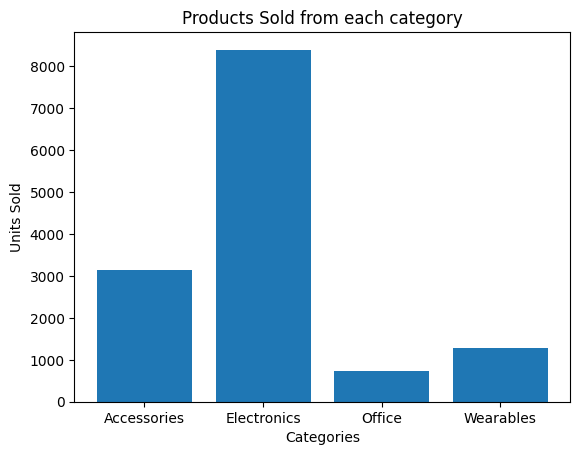

In [106]:
Categories_sold = df.groupby("Category")["Units_Sold"].sum()

plt.bar(Categories_sold.index, Categories_sold.values)
plt.title("Products Sold from each category")
plt.xlabel("Categories")
plt.ylabel("Units Sold")
plt.show()



In [27]:
# 2. What is the highest-priced product in each category?

In [28]:
Category_price = df.groupby("Category")["Price"].max()
Category_price

Category
Accessories     4321.18
Electronics    61510.12
Office         13805.80
Wearables      10790.74
Name: Price, dtype: float64

In [29]:
# 3.Maximum Discount on Which Category

In [30]:
max_discount = df.groupby("Category")["Discount"].max()
print(max_discount)

Category
Accessories    20.0
Electronics    20.0
Office         20.0
Wearables      20.0
Name: Discount, dtype: float64


In [31]:
# 4. Product demand within category

In [32]:
product_demand = df.groupby(["Category", "Product_ID"])["Demand"].sum().sort_values(ascending=False)
print(product_demand)

Category     Product_ID
Electronics  P002          2410
             P001          2347
             P004          1463
Accessories  P003          1340
Wearables    P009          1293
Electronics  P005          1287
Accessories  P007          1175
Electronics  P010          1000
Office       P008           785
Accessories  P006           762
Name: Demand, dtype: int64


In [33]:
# 5. What percentage of our data/sales comes from each region?

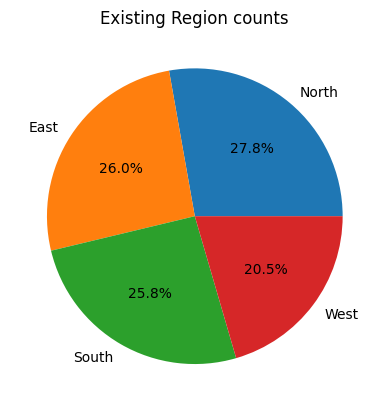

In [107]:
region_count = df["Region"].value_counts()

plt.pie(
    region_count.values,
    labels=region_count.index,
    autopct="%1.1f%%"
)
plt.title("Existing Region counts")
plt.show()

In [35]:
# 6. Which region has the highest demand?

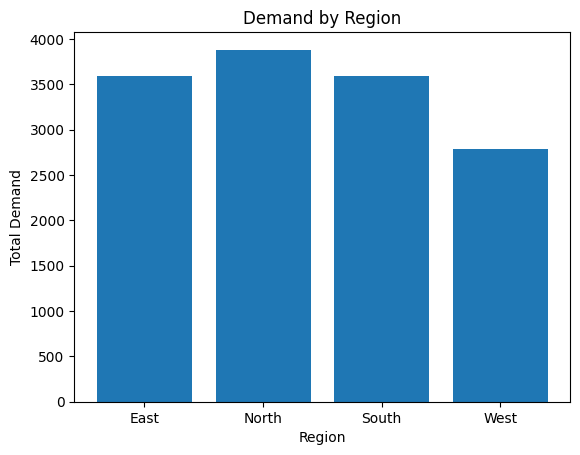

In [36]:
region_demand = df.groupby("Region")["Demand"].sum()

plt.bar(region_demand.index, region_demand.values)
plt.xlabel("Region")
plt.ylabel("Total Demand")
plt.title("Demand by Region")
plt.show()

In [ ]:
# 7. Top 10 Products with Largest Price Difference

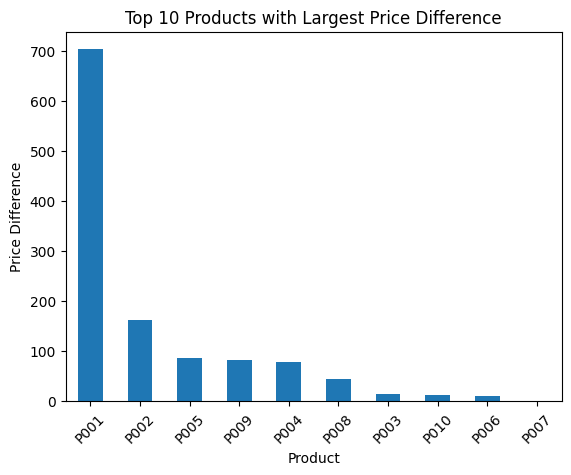

In [41]:
df["Price_Difference"] = df["Price"] - df["Competitor_Pricing"]

price_comparison = df.groupby("Product_ID")["Price_Difference"].mean().sort_values()

top_10 = price_comparison.abs().sort_values(ascending=False).head(10)

top_10.plot(kind="bar")

plt.title("Top 10 Products with Largest Price Difference")
plt.xlabel("Product")
plt.ylabel("Price Difference")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# 8. Monthly demand

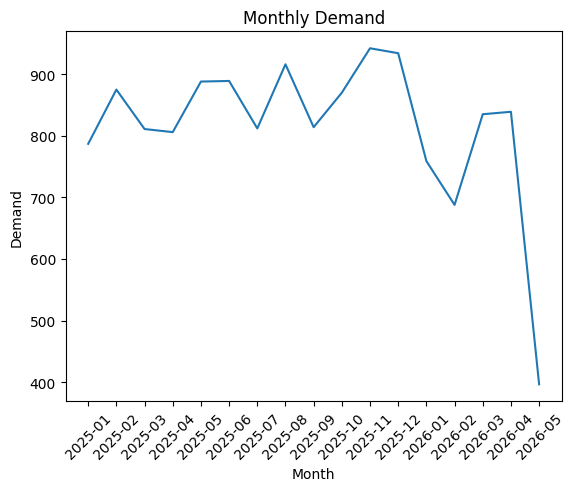

In [44]:
Monthly_demand = df.groupby(
    df["Date"].dt.to_period("M")
)["Demand"].sum()

plt.plot(Monthly_demand.index.astype(str), Monthly_demand.values)

plt.xlabel("Month")
plt.ylabel("Demand")
plt.title("Monthly Demand")
plt.xticks(rotation=45)

plt.show()

In [ ]:
# 9. Yearly Demand

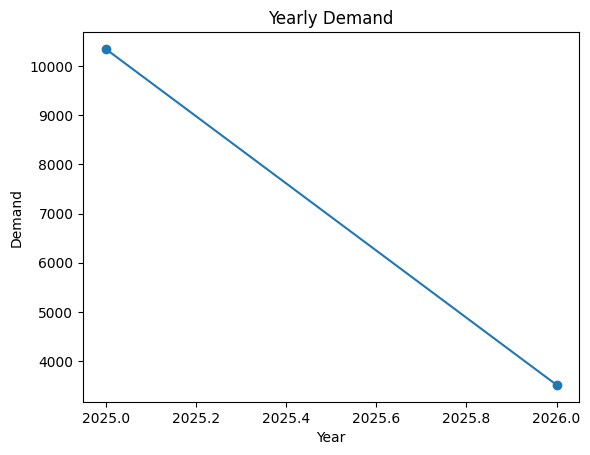

In [45]:
Yearly_demand = df.groupby(
    df["Date"].dt.year
)["Demand"].sum()

plt.plot(Yearly_demand.index, Yearly_demand.values, marker="o")

plt.xlabel("Year")
plt.ylabel("Demand")
plt.title("Yearly Demand")

plt.show()

In [ ]:
# 10. The average demand for each season.

Seasonality
Autumn    28.857143
Spring    27.238095
Summer    28.445652
Winter    27.450704
Name: Demand, dtype: float64


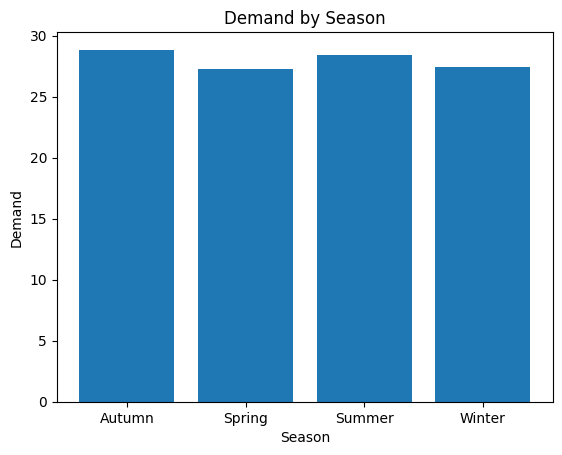

In [108]:
Seasonality_demand = df.groupby("Seasonality")["Demand"].mean()

print(Seasonality_demand)
plt.bar(Seasonality_demand.index , Seasonality_demand.values)
plt.title("Demand by Season")
plt.xlabel("Season")
plt.ylabel("Demand")
plt.show()

In [ ]:
# 11. Weather Demand

Weather_Condition
Cloudy    27.040268
Rainy     26.673684
Sunny     28.730924
Name: Demand, dtype: float64


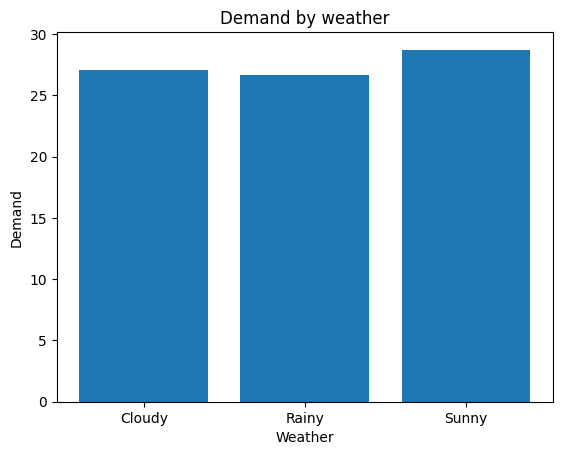

In [110]:
Weather_demand = df.groupby("Weather_Condition")["Demand"].mean()

print(Weather_demand)

plt.bar(Weather_demand.index , Weather_demand.values)
plt.title("Demand by weather")
plt.xlabel("Weather")
plt.ylabel("Demand")
plt.show()

In [56]:
df["Date"].unique()

<DatetimeArray>
['2025-01-01 00:00:00', '2025-01-02 00:00:00', '2025-01-03 00:00:00',
 '2025-01-04 00:00:00', '2025-01-05 00:00:00', '2025-01-06 00:00:00',
 '2025-01-07 00:00:00', '2025-01-08 00:00:00', '2025-01-09 00:00:00',
 '2025-01-10 00:00:00',
 ...
 '2026-05-06 00:00:00', '2026-05-07 00:00:00', '2026-05-08 00:00:00',
 '2026-05-09 00:00:00', '2026-05-10 00:00:00', '2026-05-11 00:00:00',
 '2026-05-12 00:00:00', '2026-05-13 00:00:00', '2026-05-14 00:00:00',
 '2026-05-15 00:00:00']
Length: 500, dtype: datetime64[ns]

## Feature Engineering

In [57]:
df["Lag_1"] = df["Demand"].shift(1)

In [58]:
df["Lag_7"] = df["Demand"].shift(7)

In [59]:
df[["Date", "Demand", "Lag_1", "Lag_7"]].head(10)

,Date,Demand,Lag_1,Lag_7
0,2025-01-01,24,NaN,NaN
1,2025-01-02,24,24.0,NaN
2,2025-01-03,11,24.0,NaN
3,2025-01-04,29,11.0,NaN
4,2025-01-05,27,29.0,NaN
5,2025-01-06,17,27.0,NaN
6,2025-01-07,13,17.0,NaN
7,2025-01-08,23,13.0,24.0
8,2025-01-09,14,23.0,24.0
9,2025-01-10,20,14.0,11.0


In [60]:
df[["Lag_1", "Lag_7"]].isnull().sum()

Lag_1    1
Lag_7    7
dtype: int64

In [61]:
df = df.dropna(subset=["Lag_1", "Lag_7"])

In [62]:
df[["Lag_1", "Lag_7"]].isnull().sum()

Lag_1    0
Lag_7    0
dtype: int64

In [63]:
df["Month"] = df["Date"].dt.month

C:\Users\Sejal Jha\AppData\Local\Temp\ipykernel_27804\1957367309.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Month"] = df["Date"].dt.month


In [65]:
df["Day_of_Week"] = df["Date"].dt.dayofweek

C:\Users\Sejal Jha\AppData\Local\Temp\ipykernel_27804\2440047050.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Day_of_Week"] = df["Date"].dt.dayofweek


In [66]:
df.head()

,Date,Store_ID,Product_ID,Category,Region,Inventory_Level,Units_Sold,Units_Ordered,Price,Discount,...,Weather_Condition,Competitor_Pricing,Seasonality,Epidemic,Demand,Price_Difference,Lag_1,Lag_7,Month,Day_of_Week
7,2025-01-08,S003,P007,Accessories,North,29,23,44,1067.15,5.0,...,Sunny,1102.64,Winter,0,23,-35.49,13.0,24.0,1,2
8,2025-01-09,S004,P008,Office,North,58,14,0,11818.67,20.0,...,Sunny,11901.00,Winter,0,14,-82.33,23.0,24.0,1,3
9,2025-01-10,S002,P005,Electronics,South,28,20,33,17862.56,0.0,...,Sunny,16667.12,Winter,0,20,1195.44,14.0,11.0,1,4
10,2025-01-11,S004,P004,Electronics,South,100,28,0,24949.88,0.0,...,Sunny,24783.42,Winter,0,28,166.46,20.0,29.0,1,5
11,2025-01-12,S001,P008,Office,West,51,17,0,11973.94,5.0,...,Sunny,11944.63,Winter,1,17,29.31,28.0,27.0,1,6


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 493 entries, 7 to 499
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                493 non-null    datetime64[ns]
 1   Store_ID            493 non-null    object        
 2   Product_ID          493 non-null    object        
 3   Category            493 non-null    object        
 4   Region              493 non-null    object        
 5   Inventory_Level     493 non-null    int64         
 6   Units_Sold          493 non-null    int64         
 7   Units_Ordered       493 non-null    int64         
 8   Price               493 non-null    float64       
 9   Discount            493 non-null    float64       
 10  Promotion           493 non-null    int64         
 11  Weather_Condition   493 non-null    object        
 12  Competitor_Pricing  493 non-null    float64       
 13  Seasonality         493 non-null    object        
 14 

## Encoding Categorical Variables

In [68]:
categorical_cols = [
    "Store_ID",
    "Product_ID",
    "Category",
    "Region",
    "Weather_Condition",
    "Seasonality"
]

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoded_data = encoder.fit_transform(df[categorical_cols])

In [69]:
numerical_cols = [
    "Inventory_Level",
    "Units_Ordered",
    "Price",
    "Discount",
    "Promotion",
    "Competitor_Pricing",
    "Epidemic",
    "Price_Difference",
    "Lag_1",
    "Lag_7",
    "Month",
    "Day_of_Week"
]

numerical_data = df[numerical_cols]

import numpy as np

X = np.hstack([numerical_data, encoded_data])

In [70]:
y = df["Demand"]

In [73]:
X.shape

(493, 42)

In [74]:
y.shape

(493,)

## Train and Test split

In [75]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

## Model Building

In [77]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [78]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [79]:
y_pred = model.predict(X_test)

In [80]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [81]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 4.31


In [82]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 5.464643842304119


In [83]:
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("MAPE:", mape)

MAPE: 22.938143438104753


In [84]:
comparison = pd.DataFrame({
    "Actual_Demand": y_test.values,
    "Predicted_Demand": y_pred
})

print(comparison.head(10))

   Actual_Demand  Predicted_Demand
0             35             33.32
1             22             23.82
2             19             27.29
3             19             15.07
4             20             22.56
5             15             22.69
6             15             23.92
7             20             26.07
8             33             35.01
9             22             24.51


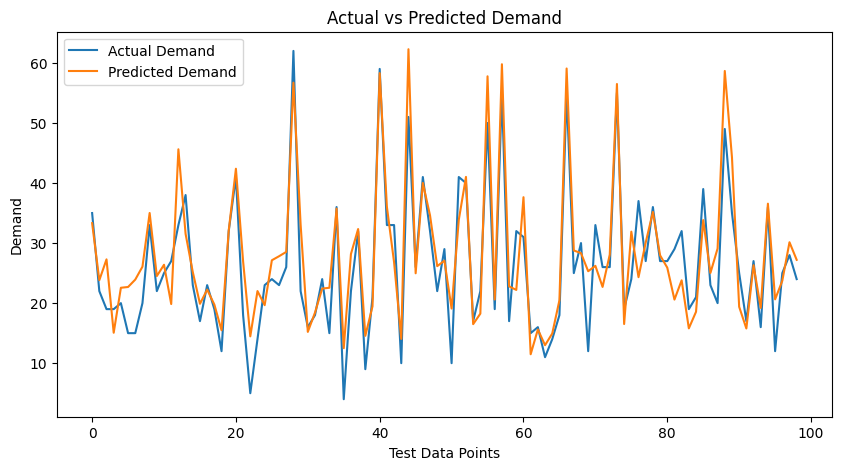

In [85]:
plt.figure(figsize=(10, 5))

plt.plot(comparison["Actual_Demand"].values, label="Actual Demand")
plt.plot(comparison["Predicted_Demand"].values, label="Predicted Demand")

plt.xlabel("Test Data Points")
plt.ylabel("Demand")
plt.title("Actual vs Predicted Demand")
plt.legend()

plt.show()

## Feature Importance

In [86]:
importance = model.feature_importances_

encoded_feature_names = encoder.get_feature_names_out(categorical_cols)

feature_names = numerical_cols + list(encoded_feature_names)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance.head(10))

               Feature  Importance
18     Product_ID_P002    0.521190
0      Inventory_Level    0.206830
2                Price    0.052907
5   Competitor_Pricing    0.044167
17     Product_ID_P001    0.029897
1        Units_Ordered    0.020396
7     Price_Difference    0.014522
8                Lag_1    0.011924
9                Lag_7    0.011556
24     Product_ID_P008    0.008509


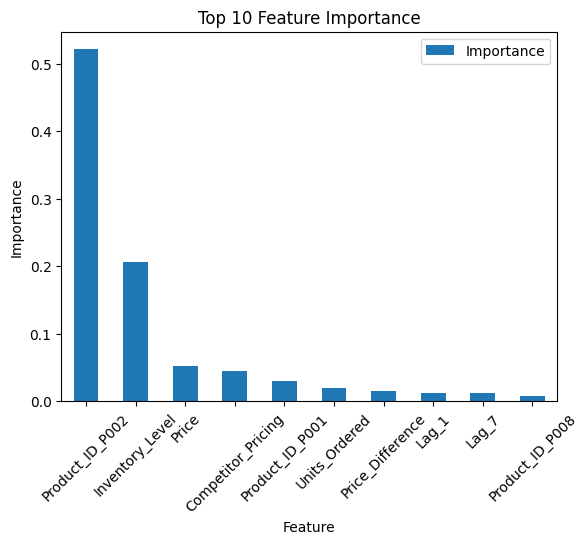

In [87]:
top_features = feature_importance.head(10)

top_features.plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Top 10 Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [88]:
prediction_df = pd.DataFrame({
    "Actual_Demand": y_test.values,
    "Predicted_Demand": y_pred
})

prediction_df.head()

,Actual_Demand,Predicted_Demand
0,35,33.32
1,22,23.82
2,19,27.29
3,19,15.07
4,20,22.56


In [89]:
safety_stock = 0.2 * prediction_df["Predicted_Demand"]

In [90]:
prediction_df["Safety_Stock"] = safety_stock

prediction_df["Recommended_Inventory"] = (
    prediction_df["Predicted_Demand"] +
    prediction_df["Safety_Stock"]
)

prediction_df.head()

,Actual_Demand,Predicted_Demand,Safety_Stock,Recommended_Inventory
0,35,33.32,6.664,39.984
1,22,23.82,4.764,28.584
2,19,27.29,5.458,32.748
3,19,15.07,3.014,18.084
4,20,22.56,4.512,27.072


In [91]:
prediction_df["Current_Inventory"] = df["Inventory_Level"].iloc[split:].values

In [92]:
prediction_df["Recommended_Order"] = (
    prediction_df["Recommended_Inventory"] -
    prediction_df["Current_Inventory"]
)

In [93]:
prediction_df["Recommended_Order"] = (
    prediction_df["Recommended_Order"].clip(lower=0)
)

In [94]:
prediction_df.head()

,Actual_Demand,Predicted_Demand,Safety_Stock,Recommended_Inventory,Current_Inventory,Recommended_Order
0,35,33.32,6.664,39.984,43,0.0
1,22,23.82,4.764,28.584,59,0.0
2,19,27.29,5.458,32.748,66,0.0
3,19,15.07,3.014,18.084,29,0.0
4,20,22.56,4.512,27.072,84,0.0


In [95]:
prediction_df["Restock_Status"] = np.where(
    prediction_df["Recommended_Order"] > 0,
    "Needs Restocking",
    "Sufficient Inventory"
)

In [96]:
prediction_df.head()

,Actual_Demand,Predicted_Demand,Safety_Stock,Recommended_Inventory,Current_Inventory,Recommended_Order,Restock_Status
0,35,33.32,6.664,39.984,43,0.0,Sufficient Inventory
1,22,23.82,4.764,28.584,59,0.0,Sufficient Inventory
2,19,27.29,5.458,32.748,66,0.0,Sufficient Inventory
3,19,15.07,3.014,18.084,29,0.0,Sufficient Inventory
4,20,22.56,4.512,27.072,84,0.0,Sufficient Inventory


In [97]:
restock_count = (prediction_df["Recommended_Order"] > 0).sum()

print("Records needing restocking:", restock_count)

Records needing restocking: 5


In [98]:
total_order_quantity = prediction_df["Recommended_Order"].sum()

print("Total recommended order quantity:", total_order_quantity)

Total recommended order quantity: 26.64


In [102]:
prediction_df.to_csv("Inventory_Optimization.csv", index=False)